In [1]:
import os, json
import numpy as np
import pandas as pd

# Fix: protobuf 6.x + TF can throw "MessageFactory has no attribute GetPrototype" if C++ impl is used.
# Force pure-Python protobuf implementation BEFORE importing tensorflow.
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION"] = "python"
os.environ["PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION_VERSION"] = "2"
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

try:
    tf.config.experimental.enable_op_determinism(True)
except Exception:
    pass

try:
    tf.config.optimizer.set_jit(True)
except Exception:
    pass

AUTOTUNE = tf.data.AUTOTUNE

print("TF version:", tf.__version__)
print("Eager:", tf.executing_eagerly())



2026-01-14 06:12:12.169409: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768371132.183475      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768371132.187782      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

TF version: 2.18.0
Eager: True


In [2]:
base_dir = "../input/cassava-leaf-disease-classification"
if not os.path.exists(base_dir):
    alt = "/kaggle/input/cassava-leaf-disease-classification"
    if os.path.exists(alt):
        base_dir = alt
    else:
        # Fallback for the provided environment listing
        alt2 = "/kaggle/data/cassava-leaf-disease-classification"
        if os.path.exists(alt2):
            base_dir = alt2

print("base_dir:", base_dir)
print("base_dir files:", os.listdir(base_dir)[:10])



base_dir: ../input/cassava-leaf-disease-classification
base_dir files: ['train.csv.zip', 'sample_submission.csv.zip', 'test.zip', 'test_tfrecords.zip', 'train_tfrecords.zip', 'test_images.zip', 'train.csv', 'test_images', 'test_tfrecords', 'cassava-leaf-disease-classification']


In [3]:
train_labels = pd.read_csv(os.path.join(base_dir, "train.csv"))
train_labels.head()



,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


In [4]:
BATCH_SIZE = 20
EPOCHS = 10
TARGET_SIZE = 224

STEPS_PER_EPOCH = int(np.ceil(len(train_labels) * 0.8 / BATCH_SIZE))
VALIDATION_STEPS = int(np.ceil(len(train_labels) * 0.2 / BATCH_SIZE))

GEN_WORKERS = max(2, (os.cpu_count() or 2) - 1)
GEN_MAX_QUEUE_SIZE = 32

print(
    "steps/epoch:",
    STEPS_PER_EPOCH,
    "val_steps:",
    VALIDATION_STEPS,
    "workers:",
    GEN_WORKERS,
)



steps/epoch: 749 val_steps: 188 workers: 31


In [5]:
train_labels = train_labels.copy()
train_labels["label"] = train_labels["label"].astype(np.int32)

train_img_dir = os.path.join(base_dir, "train_images")

shuffled = train_labels.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
split_idx = int(len(shuffled) * 0.8)
train_df = shuffled.iloc[:split_idx].reset_index(drop=True)
val_df = shuffled.iloc[split_idx:].reset_index(drop=True)

train_paths = (train_img_dir + "/" + train_df["image_id"].values).astype(str)
train_y = train_df["label"].values.astype(np.int32)

val_paths = (train_img_dir + "/" + val_df["image_id"].values).astype(str)
val_y = val_df["label"].values.astype(np.int32)

rotation_range = 40.0 * np.pi / 180.0
zoom_range = 0.2
shear_range = 0.2
height_shift_range = 0.2
width_shift_range = 0.2


def _decode_resize(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.image.resize(
        img,
        [TARGET_SIZE, TARGET_SIZE],
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=False,
    )
    img = tf.cast(img, tf.float32) / 255.0  # rescale=1./255
    return img


try:
    import tensorflow_addons as tfa

    _HAS_TFA = True
except Exception as e:
    print(
        "Warning: tensorflow_addons not available, falling back to no rotate/shear. Error:",
        repr(e),
    )
    _HAS_TFA = False
    tfa = None


def _augment(img, seed):
    img = tf.image.stateless_random_flip_left_right(img, seed=tf.stack([seed, 1]))
    img = tf.image.stateless_random_flip_up_down(img, seed=tf.stack([seed, 2]))

    if _HAS_TFA:
        angle = tf.random.stateless_uniform(
            [], seed=tf.stack([seed, 3]), minval=-rotation_range, maxval=rotation_range
        )
        img = tfa.image.rotate(
            img, angles=angle, interpolation="BILINEAR", fill_mode="nearest"
        )

    z = tf.random.stateless_uniform(
        [], seed=tf.stack([seed, 4]), minval=1.0 - zoom_range, maxval=1.0 + zoom_range
    )
    new_size = tf.cast(tf.round(tf.cast(TARGET_SIZE, tf.float32) * z), tf.int32)
    new_size = tf.maximum(new_size, 1)
    img2 = tf.image.resize(
        img,
        [new_size, new_size],
        method=tf.image.ResizeMethod.BILINEAR,
        antialias=False,
    )
    img2 = tf.image.resize_with_crop_or_pad(img2, TARGET_SIZE, TARGET_SIZE)
    img = img2

    if _HAS_TFA:
        sx = tf.random.stateless_uniform(
            [], seed=tf.stack([seed, 5]), minval=-shear_range, maxval=shear_range
        )
        sy = tf.random.stateless_uniform(
            [], seed=tf.stack([seed, 6]), minval=-shear_range, maxval=shear_range
        )
        tx = (
            tf.random.stateless_uniform(
                [],
                seed=tf.stack([seed, 7]),
                minval=-width_shift_range,
                maxval=width_shift_range,
            )
            * TARGET_SIZE
        )
        ty = (
            tf.random.stateless_uniform(
                [],
                seed=tf.stack([seed, 8]),
                minval=-height_shift_range,
                maxval=height_shift_range,
            )
            * TARGET_SIZE
        )

        a0 = 1.0
        a1 = tf.tan(sx)
        a2 = tx
        b0 = tf.tan(sy)
        b1 = 1.0
        b2 = ty
        c0 = 0.0
        c1 = 0.0
        transform = tf.stack([a0, a1, a2, b0, b1, b2, c0, c1])
        img = tfa.image.transform(
            img, transform, interpolation="BILINEAR", fill_mode="nearest"
        )

    return img


def make_dataset(paths, labels=None, training=False):
    if labels is None:
        ds = tf.data.Dataset.from_tensor_slices(paths)
    else:
        ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    options = tf.data.Options()
    options.deterministic = True
    ds = ds.with_options(options)

    if training:
        ds = ds.shuffle(
            buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True
        )

    if labels is None:

        def _map_fn(idx, path):
            img = _decode_resize(path)
            if training:
                img = _augment(img, tf.cast(idx, tf.int32))
            return img

        ds = ds.enumerate()
        ds = ds.map(_map_fn, num_parallel_calls=AUTOTUNE)
    else:

        def _map_fn(idx, xy):
            path, y = xy[0], xy[1]
            img = _decode_resize(path)
            if training:
                img = _augment(img, tf.cast(idx, tf.int32))
            return img, y

        ds = ds.enumerate()
        ds = ds.map(_map_fn, num_parallel_calls=AUTOTUNE)

    ds = ds.batch(BATCH_SIZE, drop_remainder=False)
    ds = ds.prefetch(AUTOTUNE)
    return ds


train_ds = make_dataset(train_paths, train_y, training=True)
val_ds = make_dataset(val_paths, val_y, training=False)

print("Train/val sizes:", len(train_df), len(val_df))



I0000 00:00:1768371139.501699      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 40007 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:06:00.0, compute capability: 8.6


Train/val sizes: 14976 3745


In [6]:
from tensorflow.keras.applications import EfficientNetB0

eff_base = EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(TARGET_SIZE, TARGET_SIZE, 3),
)
eff_base.summary()



16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 224, 224,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 224, 224,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 225, 225,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 112, 112,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 112, 112,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 112, 112,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 112, 112,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 112, 112,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 112, 112,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 112, 112,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 112, 112,  │        512 │ block1a_se_excit

 Total params: 4,049,571 (15.45 MB)

 Trainable params: 4,007,548 (15.29 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [7]:
model = models.Sequential()
model.add(eff_base)
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(5, activation="softmax", name="Output"))
model.summary()



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 4,013,953 (15.31 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [8]:
model.compile(
    optimizer="Adam",
    loss="sparse_categorical_crossentropy",
    metrics=["acc"],
    jit_compile=True,
    steps_per_execution=32,
)



In [9]:
model_save = ModelCheckpoint(
    "./EffNetB0_512_8_best_weights.weights.h5",
    save_best_only=True,
    save_weights_only=True,
    monitor="val_loss",
    mode="min",
    verbose=0,
)
early_stop = EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=5,
    mode="min",
    verbose=1,
    restore_best_weights=True,
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_delta=0.001,
    mode="min",
    verbose=1,
)



In [10]:
history = model.fit(
    train_ds,
    steps_per_epoch=STEPS_PER_EPOCH,
    epochs=EPOCHS,
    validation_data=val_ds,
    validation_steps=VALIDATION_STEPS,
    callbacks=[model_save, early_stop, reduce_lr],
    verbose=1,
)



Epoch 1/10


I0000 00:00:1768371159.205213      61 service.cc:148] XLA service 0x7f1d1c004a40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1768371159.205284      61 service.cc:156]   StreamExecutor device (0): NVIDIA RTX A6000, Compute Capability 8.6
I0000 00:00:1768371159.217640      61 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1768371159.254215      61 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


749/749 ━━━━━━━━━━━━━━━━━━━━ 105s 65ms/step - acc: 0.7034 - loss: 0.8270 - val_acc: 0.1194 - val_loss: 1.8543 - learning_rate: 0.0010
Epoch 2/10
749/749 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - acc: 0.7957 - loss: 0.5767 - val_acc: 0.1194 - val_loss: 3.0410 - learning_rate: 0.0010
Epoch 3/10
737/749 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.8141 - loss: 0.5209
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
749/749 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - acc: 0.8141 - loss: 0.5210 - val_acc: 0.1194 - val_loss: 2.2439 - learning_rate: 0.0010
Epoch 4/10
749/749 ━━━━━━━━━━━━━━━━━━━━ 21s 26ms/step - acc: 0.8485 - loss: 0.4308 - val_acc: 0.2550 - val_loss: 1.9729 - learning_rate: 3.0000e-04
Epoch 5/10
737/749 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - acc: 0.8610 - loss: 0.3925
Epoch 5: ReduceLROnPlateau reducing learning rate to 9.000000427477062e-05.
749/749 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - acc: 0.8610 - loss: 0.3926 - val_acc: 0.1055 - val_loss: 2.6486 - learning_rate:

/tmp/ipykernel_11/961735572.py:20: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bo" (-> color='b'). The keyword argument will take precedence.
  ax2.plot(epochs_range, loss, "bo", label="Training loss", color="red")
/tmp/ipykernel_11/961735572.py:21: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax2.plot(epochs_range, val_loss, "b", label="Validation loss", color="red")


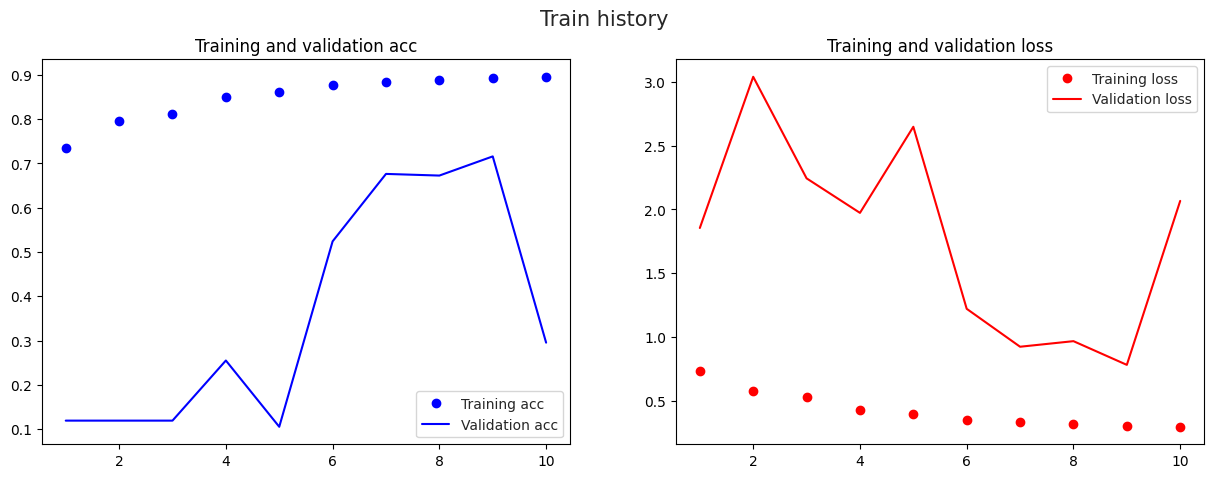

In [11]:
acc = history.history.get("acc", history.history.get("accuracy", []))
val_acc = history.history.get("val_acc", history.history.get("val_accuracy", []))
loss = history.history.get("loss", [])
val_loss = history.history.get("val_loss", [])

epochs_range = range(1, len(loss) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
sns.set_style("white")
plt.suptitle("Train history", size=15)

if len(acc) and len(val_acc):
    ax1.plot(epochs_range, acc, "bo", label="Training acc")
    ax1.plot(epochs_range, val_acc, "b", label="Validation acc")
    ax1.set_title("Training and validation acc")
    ax1.legend()
else:
    ax1.set_title("Accuracy history unavailable (key mismatch)")

ax2.plot(epochs_range, loss, "bo", label="Training loss", color="red")
ax2.plot(epochs_range, val_loss, "b", label="Validation loss", color="red")
ax2.set_title("Training and validation loss")
ax2.legend()

plt.show()



In [12]:
sub = pd.read_csv(os.path.join(base_dir, "sample_submission.csv"))
sub.head()



,image_id,label
0,1234294272.jpg,4
1,1234332763.jpg,4
2,1234375577.jpg,4
3,1234555380.jpg,4
4,1234571117.jpg,4


In [13]:
test_dir = os.path.join(base_dir, "test_images")
test_df = sub[["image_id"]].copy()
test_paths = (test_dir + "/" + test_df["image_id"].values).astype(str)

test_ds = make_dataset(test_paths, labels=None, training=False)
test_steps = int(np.ceil(len(test_df) / BATCH_SIZE))

probs = model.predict(
    test_ds,
    steps=test_steps,
    verbose=0,
)

preds = np.argmax(probs, axis=1).astype(int)[: len(test_df)]
sub["label"] = preds
sub.head()



,image_id,label
0,1234294272.jpg,3
1,1234332763.jpg,3
2,1234375577.jpg,3
3,1234555380.jpg,1
4,1234571117.jpg,3


In [14]:
sub = sub[["image_id", "label"]]
sub.to_csv("submission.csv", index=False)
print("Wrote submission.csv with shape:", sub.shape)
print(sub.head())

Wrote submission.csv with shape: (2676, 2)
         image_id  label
0  1234294272.jpg      3
1  1234332763.jpg      3
2  1234375577.jpg      3
3  1234555380.jpg      1
4  1234571117.jpg      3
